Market Analysis
These questions investigate general EV trends within all of the United States.

1) Which fifteen states have the most EV registrations? (ArcGIS)
1a) To further this exploration, which states prefer PHEVs versus BEVs in the United States?
2) Which ten counties and cities have the highest amount of EVs, split by PHEVs and BEVs? 
3) How does the count of EVs change over time in the top 10 counties?
4) What are the top ten most popular brands of cars?
5) What are the top ten most popular EV brands, model and model year?
6) How have the number of PHEVs and BEVs changed over the years?
7) How does Minimum and Maximum Electric Ranges change depending on brands?
8) How have Electric Ranges changed over the years?
DONE DONE DONE

Dealership Analysis
These questions look at the most popular counties and cities in Washington State, as we saw that the demand for EVs in Washington State was highest.

Which counties represent the strongest EV demand hotspots for dealership placement?
Which regions show a stronger preference for BEVs vs PHEVs, and how should that influence dealership inventory strategy?
Which non-Tesla manufacturers dominate EV demand in high-adoption regions?
Which EV models should dealerships prioritize based on regional demand patterns?
How does electric range vary across EV types and manufacturers, and what does that imply for dealership positioning?
How has electric range improved across model years, and what does this suggest about evolving consumer expectations?

In [49]:
import duckdb 
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [50]:
def plot_bar(reset_theme, small_text, data, x, y, title, x_axis=None, y_axis=None, hue=None, despine=None):
    sns.set_theme(style="whitegrid")
    
    if reset_theme:
        plt.rcdefaults()
        sns.set_theme(style="whitegrid")

    if small_text:
        sns.set_theme(style='whitegrid', font_scale=0.7)

    plot = sns.barplot(data=data, x=x, y=y, hue=hue)
    
    if x_axis is not None:
        plot.set_xlabel(x_axis)
    
    if y_axis is not None:
        plot.set_ylabel(y_axis)
    
    plot.set_title(label=title)
    # adding labels to each bar, more info found here: https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/
    for container in plot.containers:
        plot.bar_label(container, padding=2)

    if despine == 'bottom':
        sns.despine(bottom = True)
    elif despine == 'left':
        sns.despine(left=True)
    else:
        None
        
    plt.show()

In [51]:
df = pd.read_csv("../data/cleaned/data_wo_fuel.csv")

In [52]:
# We can define a new dataframe using the following for calculations that involve electric range:
df_elec = df[df['Electric Range (in Miles)'].notnull()]

Market Analysis

**Which fifteen states have the most EV registrations? (w/ GeoPandas)**

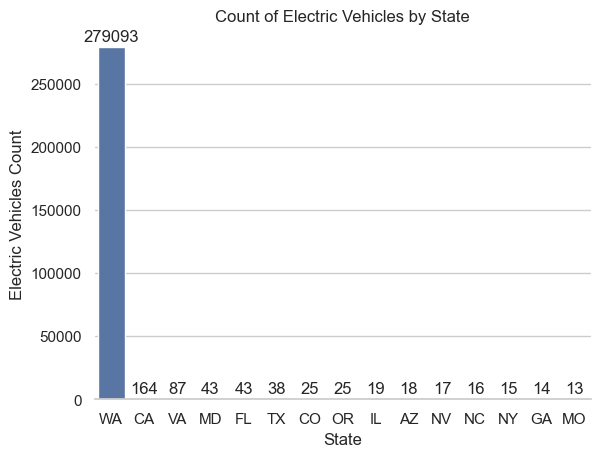

In [61]:
top_fifteen_states = duckdb.sql("""
                                SELECT State, COUNT(*) AS Count from df
                                GROUP BY State
                                ORDER BY Count DESC
                                LIMIT 15
                                """).df()

plot_bar(False, False, top_fifteen_states, 'State', 'Count', 'Count of Electric Vehicles by State', y_axis = 'Electric Vehicles Count', despine = 'left')

Using the above plot, we can see that the Washington State has the highest amount of Electric Vehicles registered. 

In order to see the count of EVs in other states, we will have to limit one of the plots to the fourteen States besides Washington State seen in the above bar chart.

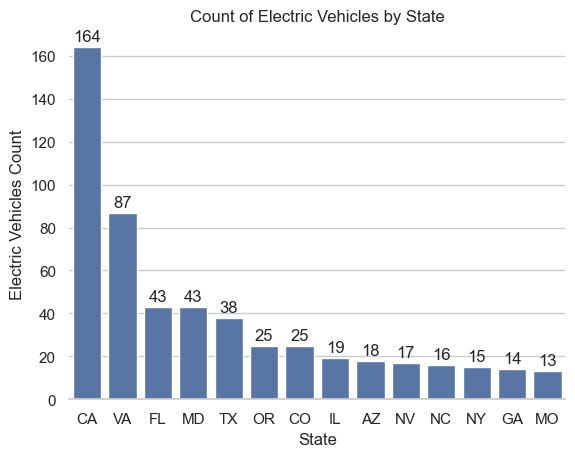

In [54]:
plot_bar(False, False, top_fifteen_states[1:], 'State', 'Count', 'Count of Electric Vehicles by State', y_axis = 'Electric Vehicles Count', despine="left")

From the above bar charts, we can see that...

2) To further this exploration, which states prefer PHEVs versus BEVs in the United States? Which regions show a stronger preference for BEVs and PHEVs, and how should that influence dealership inventory strategy?

In [55]:
electric_types = duckdb.sql("""
                            SELECT State, MODE("Electric Vehicle Type") AS Type from df
                            GROUP BY State
                            """).df()
electric_types.head()

,State,Type
0,NC,Battery Electric (BEV)
1,HI,Battery Electric (BEV)
2,WA,Battery Electric (BEV)
3,NY,Plug-in Hybrid (PHEV)
4,PA,Battery Electric (BEV)


We can also plot the distribution of the vehicles using plotly, as can be seen here in their documentation: https://plotly.com/python/choropleth-maps/

In [56]:
fig = px.choropleth(data_frame=electric_types, locations='State', locationmode="USA-states", color='Type', scope='usa')
fig

3) Which ten counties, cities, and states have the highest amount of EVs, split by PHEVs and BEVs? Which counties represent the strongest EV demand hotspots for dealership placement?

First, let's see the top ten counties and cities with the highest amount of EVs:

In [57]:
top_counties_cities = duckdb.sql("""
                            SELECT County, City, State, COUNT(*) AS Count from df
                            GROUP BY County, City, State
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
top_counties_cities

,County,City,State,Count
0,King,Seattle,WA,43250
1,King,Bellevue,WA,13683
2,Clark,Vancouver,WA,10395
3,King,Redmond,WA,9606
4,King,Kirkland,WA,7978
5,King,Sammamish,WA,7798
6,King,Renton,WA,7647
7,Snohomish,Bothell,WA,7273
8,Thurston,Olympia,WA,6508
9,Pierce,Tacoma,WA,6072


Since the state in the above table is always Washington, we can leave the State out in the following step.

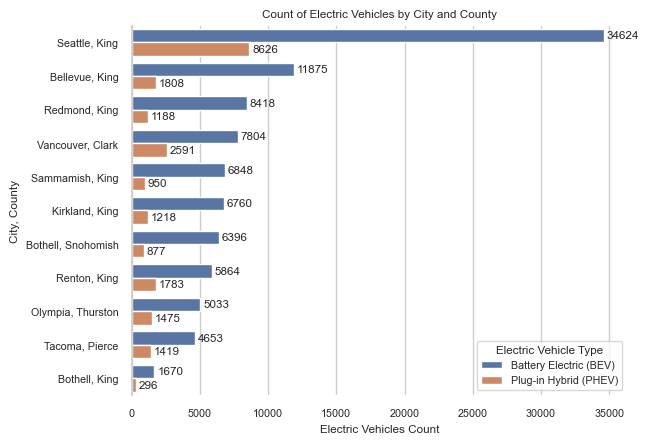

In [58]:
# Now, we use IN with the counties we found in the first step like so: https://stackoverflow.com/a/29749286
top_counties = top_counties_cities['County'].tolist()
top_cities = top_counties_cities['City'].tolist()

top_evs_county_city = duckdb.sql(f"""
                            SELECT County, City, "Electric Vehicle Type", COUNT(*) AS Count from df
                            WHERE County IN {top_counties} AND City IN {top_cities}
                            GROUP BY County, City, "Electric Vehicle Type"
                            ORDER BY Count DESC
                            """).df()

top_evs_county_city["City, County"] = top_evs_county_city["City"] + ", " + top_evs_county_city["County"] 
plot_bar(False, True, top_evs_county_city, 'Count', 'City, County', 'Count of Electric Vehicles by City and County', x_axis = 'Electric Vehicles Count', hue = 'Electric Vehicle Type', despine='bottom')

From the above graph, we can see...

4) What are the counties and states with the most EVs?

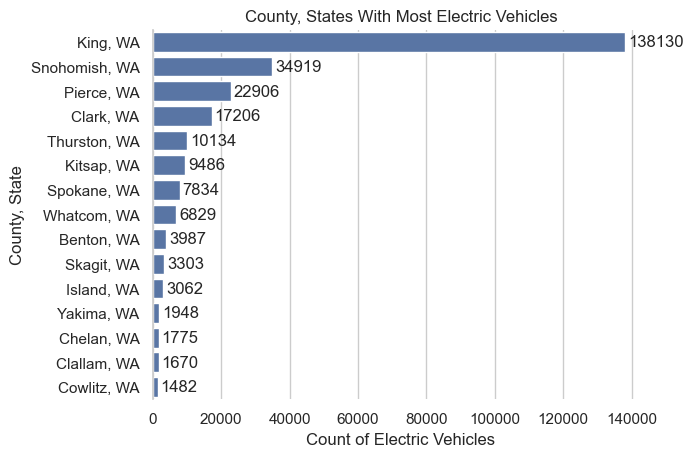

In [59]:
pop_county_states = duckdb.sql("""
                    SELECT County, State, COUNT(County) AS Count FROM df
                    GROUP BY County, State
                    ORDER BY Count DESC
                    LIMIT 15
                    """).df()
pop_county_states["County, State"] = pop_county_states["County"] + ", " + pop_county_states["State"]
plot_bar(False, False, pop_county_states, 'Count', 'County, State', 'County, States With Most Electric Vehicles', x_axis='Count of Electric Vehicles', despine='bottom')

How does the count of EVs model years change over time in the top 10 counties?

TypeError: 'Axes' object is not callable

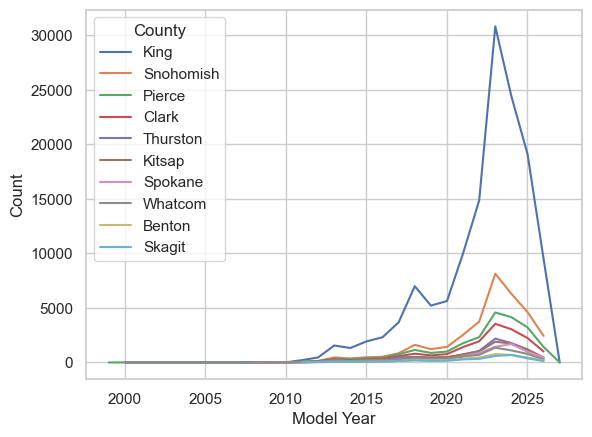

In [60]:
top_10_counties = duckdb.sql("""
                            SELECT County, COUNT(*) AS Count from df
                            GROUP BY County
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
county_list = top_10_counties['County'].tolist()

county_vs_year = duckdb.sql(f"""
                            SELECT County, "Model Year", COUNT(*) AS Count from df
                            WHERE County IN {county_list}
                            GROUP BY County, "Model Year"
                            ORDER BY Count DESC
                            """).df()
plot = sns.lineplot(county_vs_year, x='Model Year', y='Count', hue='County')
# plot_bar(reset_theme, small_text, data, x, y, title, x_axis=None, y_axis=None, hue=None):
plot(True, False, county_vs_year, 'Model Year', 'Count', 'Trends of EV Counts by Years', x_axis='Model Year', y_axis='Count of Electric Vehicles', hue='County', type='line')

4) What are the top ten most popular brands of Electric Vehicles?

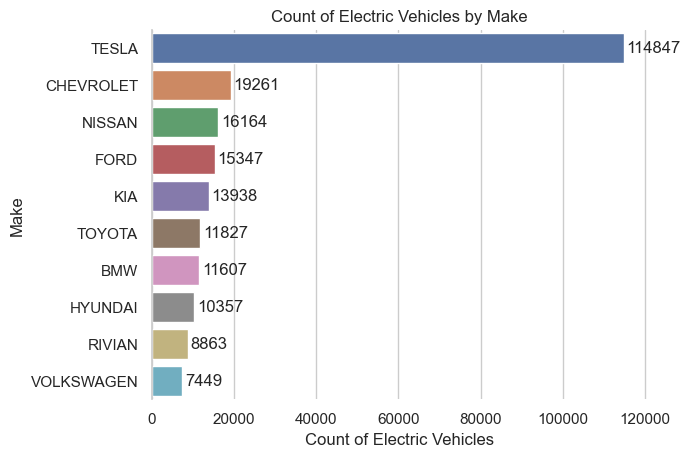

In [ ]:
top_10_makes = duckdb.sql("""
                            SELECT Make, COUNT(*) AS Count from df
                            GROUP BY Make
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()

top_makes = top_10_makes['Make'].tolist()
plot_bar(True, False, top_10_makes, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='Make')

6) How have the number of PHEVs and BEVs changed over the years?

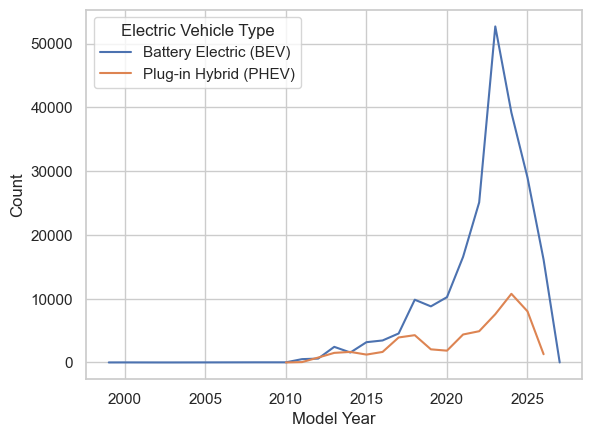

In [ ]:
yearly_dist = duckdb.sql("""
                    SELECT "Electric Vehicle Type", "Model Year", COUNT("Model Year") AS Count FROM df
                    GROUP BY "Electric Vehicle Type", "Model Year"
                    ORDER BY Count DESC
                    """).df()
sns.lineplot(yearly_dist, x="Model Year", y='Count', hue="Electric Vehicle Type")
plt.show()

7) How does Minimum and Maximum Electric Ranges change for the top EV brands?

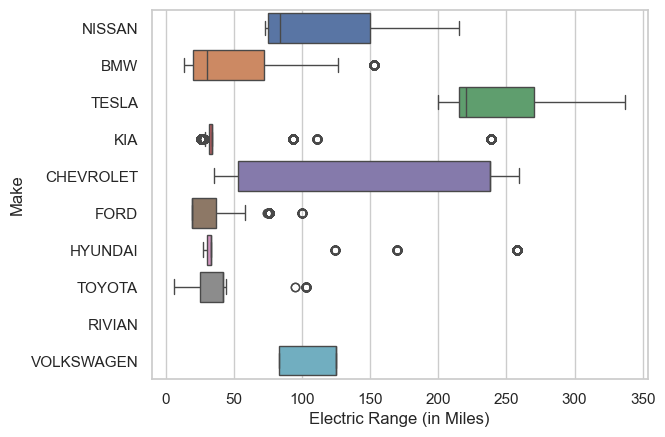

In [ ]:
elec_boxplot = duckdb.sql(f"""
                    SELECT Make, "Electric Range (in Miles)" from df
                    WHERE Make IN {top_makes}
                    """).df()
sns.boxplot(elec_boxplot, x='Electric Range (in Miles)', y='Make', hue='Make')
plt.show()

8) How have Electric Ranges changed over the years, split by Electric Vehicle Type? How has Electric Range improved across model years, and what does this suggest about evolving consumer expectations?

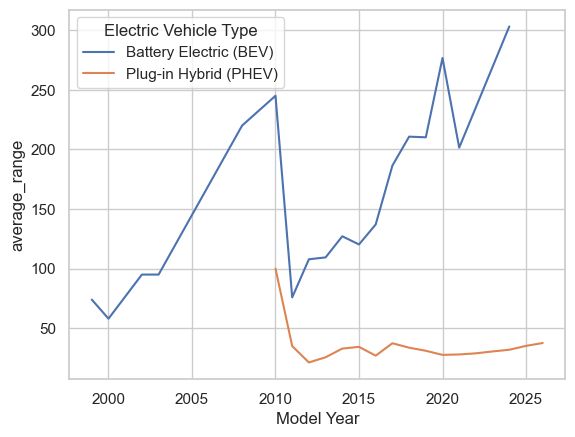

In [ ]:
pop_city = duckdb.sql("""
                    SELECT "Model Year", "Electric Vehicle Type", AVG("Electric Range (in Miles)") AS average_range from df_elec
                    GROUP BY "Model Year", "Electric Vehicle Type",
                    """).df()
sns.lineplot(pop_city, x="Model Year", y="average_range", hue="Electric Vehicle Type")
plt.show()

**Dealership Analysis**

These questions look at the most popular counties and cities in Washington State, as we saw that the demand for EVs in Washington State was highest.

Which top five non-Tesla manufacturers dominate EV demand in high-adoption regions in the top five counties?

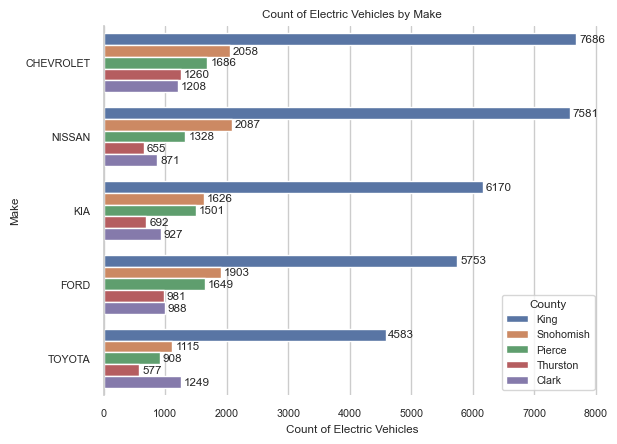

In [65]:
pop_non_tesla = duckdb.sql(f"""
                            SELECT Make, County, COUNT(*) AS Count from df
                            WHERE County IN {county_list[:5]} AND Make in {top_makes[:6]} AND Make <> 'TESLA'
                            GROUP BY Make, County
                            ORDER BY Count DESC
                            """).df()
plot_bar(False, True, pop_non_tesla, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='County')

Which EV models should dealerships prioritize based on regional demand patterns?

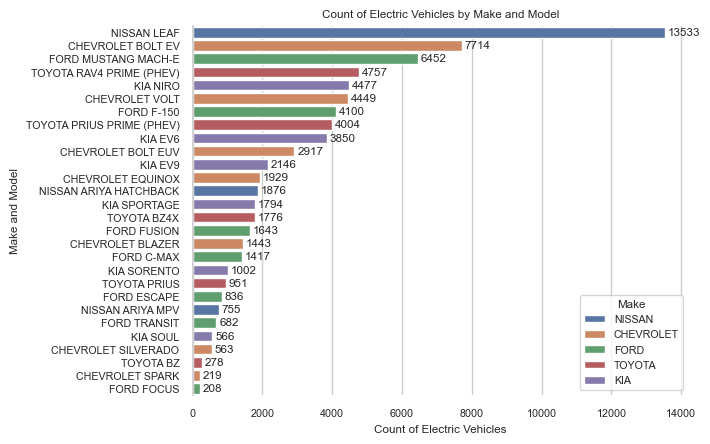

In [ ]:
pop_models = duckdb.sql(f"""
                            SELECT Make, Model, COUNT(*) AS Count from df
                            WHERE Make in {top_makes[:6]} AND Make <> 'TESLA'
                            GROUP BY Make, Model
                            HAVING Count > 200
                            ORDER BY Count DESC
                            """).df()
pop_models["Make and Model"] = pop_models["Make"] + " " + pop_models["Model"]
plot_bar(False, True, pop_models, 'Count', 'Make and Model', 'Count of Electric Vehicles by Make and Model', x_axis='Count of Electric Vehicles', despine='bottom', hue='Make')

How does electric range vary across EV types and manufacturers, and what does that imply for dealership positioning?

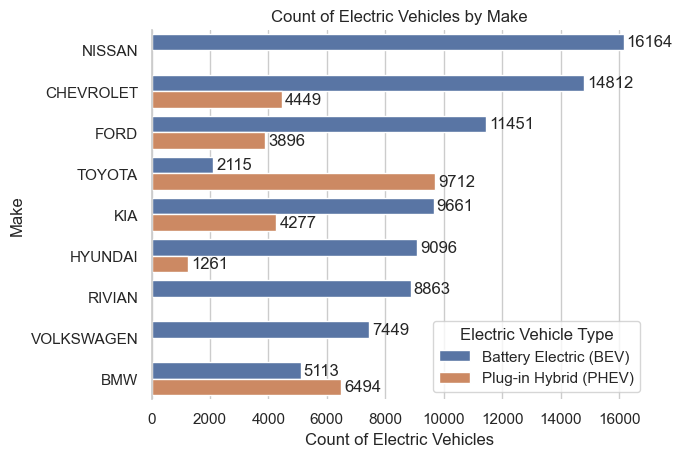

In [ ]:
pop_models = duckdb.sql(f"""
                            SELECT Make, "Electric Vehicle Type", COUNT(*) AS Count from df
                            WHERE Make in {top_makes} AND Make <> 'TESLA'
                            GROUP BY Make, "Electric Vehicle Type"
                            ORDER BY Count DESC
                            """).df()

plot_bar(True, False, pop_models, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='Electric Vehicle Type')